In [1]:
import sys
from utils import export_mft
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

sys.path.append('..')
from config import DATA_PATH
from pathlib import Path

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

In [ ]:
# # flag problem files
 
# from utils import flag_mft_dataset

# all_train_files = sorted(TRAIN_PATH.glob("*.WAV"))
# print(f"Total files: {len(all_train_files)}")

# flagged_df = flag_mft_dataset(all_train_files, output_csv="portable-data/flagged_mfts.csv")

Total files: 20265


/Users/ziyaahmad/Code/mouse_vocalization_2026/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1921
  warnings.warn(


Flagged 767 files.
Saved to: portable-data/flagged_mfts.csv


In [ ]:
# # exclude the flagged problem files, then extract + save real frequency
# # trajectories for all remaining clean files into one pickle file

# from utils import export_mft_pickle

# import pandas as pd

# flagged_df = pd.read_csv("portable-data/flagged_mfts.csv")
# print(f"Loaded {len(flagged_df)} flagged files")

# flagged_names = set(flagged_df["filename"])
# clean_files = [f for f in all_train_files if f.name not in flagged_names]
# print(f"Exporting {len(clean_files)} clean files")

# export_mft_pickle(clean_files, output_file="pkl-files/sep_14_contours.pkl")

Loaded 767 flagged files
Exporting 19498 clean files


/Users/ziyaahmad/Code/mouse_vocalization_2026/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1921
  warnings.warn(


'portable-data/sep_14_contours.pkl'

In [ ]:
# import pickle

# with open("pkl-files/sep_14_contours.pkl", "rb") as f:
#     contours = pickle.load(f)

# print(f"Loaded {len(contours)} trajectories")

# first_key = list(contours.keys())[0]
# print(first_key)
# print(contours[first_key])

Loaded 19498 trajectories
DBA_3070_0
{'time_s': array([0.00906667, 0.0096    , 0.01013333, 0.01066667, 0.0112    ,
       0.01173333, 0.01226667, 0.0128    , 0.01333333, 0.01386667,
       0.0144    , 0.01493333, 0.01546667, 0.016     , 0.01653333,
       0.01706667]), 'frequency_hz': array([99609.375 , 99609.375 , 99609.375 , 99609.375 , 99609.375 ,
       99609.375 , 99609.375 , 99609.375 , 99609.375 , 99609.375 ,
       99257.8125, 99257.8125, 99257.8125, 99257.8125, 99257.8125,
       99257.8125])}


In [2]:
import numpy as np
from scipy.interpolate import interp1d

def resample_trajectory(freqs, n_points=100):
    if len(freqs) < 2:
        return None
    x_old = np.linspace(0, 1, len(freqs))
    x_new = np.linspace(0, 1, n_points)
    f = interp1d(x_old, freqs, kind="linear")
    return f(x_new)

resampled_trajectories = []
for key, data in contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        resampled_trajectories.append(result)

print(f"Resampled {len(resampled_trajectories)} out of {len(contours)} trajectories")

NameError: name 'contours' is not defined

In [3]:
from sklearn.decomposition import PCA

X = np.stack(resampled_trajectories)
print("Data matrix shape:", X.shape)  # should be (19498, 100)

X_centered = X - X.mean(axis=1, keepdims=True)

pca_full = PCA()
pca_full.fit(X_centered)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("Cumulative variance at 1, 2, 3, 5, 10 components:")
print(cumulative_variance[0], cumulative_variance[1], cumulative_variance[2], cumulative_variance[4], cumulative_variance[9])

ValueError: need at least one array to stack

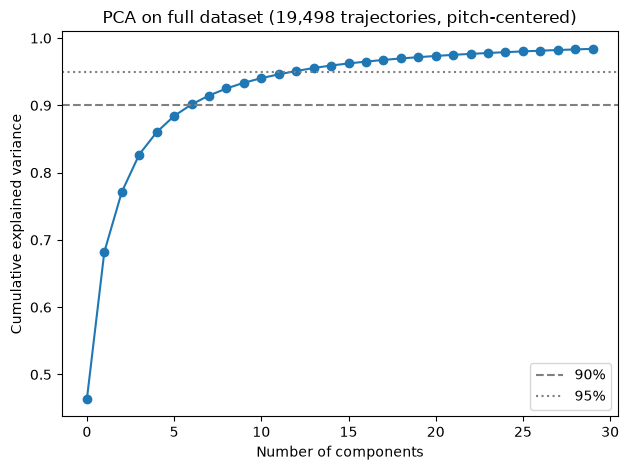

In [11]:
import matplotlib.pyplot as plt

plt.plot(cumulative_variance[:30], marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(0.90, color='gray', linestyle='--', label='90%')
plt.axhline(0.95, color='gray', linestyle=':', label='95%')
plt.legend()
plt.title("PCA on full dataset (19,498 trajectories, pitch-centered)")
plt.tight_layout()
plt.show()

In [ ]:
# save a few real, uncentered trajectories for testing in model.ipynb -> in data_prep/pkl-files/sample_trajectories.pkl

# import pickle

# sample_trajectories = resampled_trajectories[:10]  # just grab 10 real examples

# with open("sample_trajectories.pkl", "wb") as f:
#     pickle.dump(sample_trajectories, f)

# print(f"Saved {len(sample_trajectories)} sample trajectories")

Saved 10 sample trajectories
